<a href="https://colab.research.google.com/github/sonixx00/Starshun/blob/main/LB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Старшун Софія, ФІТ 2-17

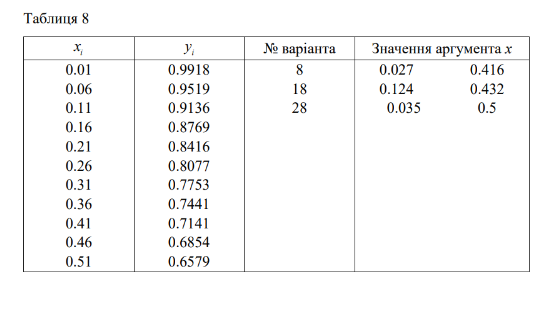

In [ ]:
import numpy as np
from math import factorial

# задані точки (ВАРІАНТ 18)
x = np.array([0.01, 0.06, 0.11, 0.16, 0.21, 0.26, 0.31, 0.36, 0.41, 0.46, 0.51])
y = np.array([0.9918, 0.9519, 0.9136, 0.8769, 0.8416, 0.8077, 0.7753, 0.7441, 0.7141, 0.6854, 0.6579])

# Перша інтерполяційна формула Ньютона (інтерполяція вперед)
def newton_forward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]  # Крок між вузлами

    # Обчислення кінцевих різниць
    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n-j):
            delta_y[i, j] = delta_y[i+1, j-1] - delta_y[i, j-1]

    # Обчислення q
    q = (x0 - x[0]) / h

    # Формула Ньютона
    ans = delta_y[0, 0]
    q_prod = 1

    for i in range(1, n):
        q_prod *= (q - i + 1)
        ans += (q_prod * delta_y[0, i]) / factorial(i)

    return ans

# Обчислення
x1 = 0.124
y1 = newton_forward_interpolation(x, y, x1)

print(f"f({x1}) = {y1}")

f(0.124) = 0.9031613104143021


In [ ]:
import numpy as np
from math import factorial

# задані точки (ВАРІАНТ 18)
x = np.array([0.01, 0.06, 0.11, 0.16, 0.21, 0.26, 0.31, 0.36, 0.41, 0.46, 0.51])
y = np.array([0.9918, 0.9519, 0.9136, 0.8769, 0.8416, 0.8077, 0.7753, 0.7441, 0.7141, 0.6854, 0.6579])

# Друга інтерполяційна формула Ньютона (інтерполяція назад)
def newton_backward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]  # Крок між вузлами

    # Обчислення кінцевих різниць
    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n-j):
            delta_y[i, j] = delta_y[i+1, j-1] - delta_y[i, j-1]

    # Обчислення q
    q = (x0 - x[-1]) / h

    # Формула Ньютона
    ans = delta_y[-1, 0]
    q_prod = 1

    for i in range(1, n):
        q_prod *= (q + i - 1)
        ans += (q_prod * delta_y[n-i-1, i]) / factorial(i)

    return ans

# Обчислення
x2 = 0.432
y2 = newton_backward_interpolation(x, y, x2)

print(f"f({x2}) = {y2}")

f(0.432) = 0.7013510924487248


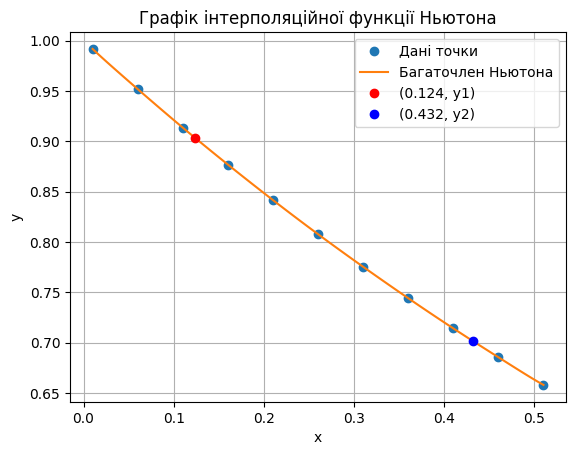

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# задані точки (ВАРІАНТ 18)
x = np.array([0.01, 0.06, 0.11, 0.16, 0.21, 0.26, 0.31, 0.36, 0.41, 0.46, 0.51])
y = np.array([0.9918, 0.9519, 0.9136, 0.8769, 0.8416, 0.8077, 0.7753, 0.7441, 0.7141, 0.6854, 0.6579])

# --- НЬЮТОН ВПЕРЕД ---
def newton_forward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]

    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n-j):
            delta_y[i, j] = delta_y[i+1, j-1] - delta_y[i, j-1]

    q = (x0 - x[0]) / h

    ans = delta_y[0, 0]
    q_prod = 1

    for i in range(1, n):
        q_prod *= (q - i + 1)
        ans += (q_prod * delta_y[0, i]) / factorial(i)

    return ans

# --- НЬЮТОН НАЗАД ---
def newton_backward_interpolation(x, y, x0):
    n = len(x)
    h = x[1] - x[0]

    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n-j):
            delta_y[i, j] = delta_y[i+1, j-1] - delta_y[i, j-1]

    q = (x0 - x[-1]) / h

    ans = delta_y[-1, 0]
    q_prod = 1

    for i in range(1, n):
        q_prod *= (q + i - 1)
        ans += (q_prod * delta_y[n-i-1, i]) / factorial(i)

    return ans

# точки для обчислення
x1 = 0.124
x2 = 0.432

y1 = newton_forward_interpolation(x, y, x1)
y2 = newton_backward_interpolation(x, y, x2)

# --- ГРАФІК ---
xx = np.linspace(np.min(x), np.max(x), 100)
yy = np.zeros_like(xx)

for i in range(len(xx)):
    if xx[i] <= x[len(x)//2]:
        yy[i] = newton_forward_interpolation(x, y, xx[i])
    else:
        yy[i] = newton_backward_interpolation(x, y, xx[i])

plt.plot(x, y, 'o', label='Дані точки')
plt.plot(xx, yy, label='Багаточлен Ньютона')
plt.plot(x1, y1, 'ro', label='(0.124, y1)')
plt.plot(x2, y2, 'bo', label='(0.432, y2)')

plt.title("Графік інтерполяційної функції Ньютона")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()